In [1]:
#
# IMPLEMENTACIÓN COMPLETA
#

# Instalación de librerias y dependencias del SOTA
!pip install -q transformers[torch] datasets accelerate torch scikit-learn sentencepiece peft bitsandbytes seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 30.1 MB/s eta 0:00:00


In [2]:
# Carga de datos y configuración
import os
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from google.colab import drive

# Montar el Drive
drive.mount('/content/drive')

# Semilla
import numpy as np
import random
import torch
import sys
import transformers
import sklearn

def set_seed(seed=42):
    """
    Fija las semillas aleatorias para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semilla fijada en: {seed}")

# Fijación de semilla
set_seed(42)

# Versiones
print(f"Python version: {sys.version}")
print(f"Transformers version: {transformers.__version__}")
print(f"Torch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("Entorno configurado para reproducibilidad.")

# Configuración general
BASE_PATH = "/content/drive/MyDrive/TFG_Data/PROCESSED"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de entrenamiento: {DEVICE}")

# Carga de datos
def load_dataset_for_training(filename, sample_size=None):
    path = os.path.join(BASE_PATH, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encuentra el archivo: {path}")

    df = pd.read_csv(path)
    df = df.dropna(subset=['text', 'label'])

    # Enteros
    df['label'] = df['label'].astype(int)

    # Debugging
    if sample_size:
        df = df.head(sample_size)
        print(f"MODO PRUEBA: Cargando solo {sample_size} filas.")
    else:
        print(f"Cargando dataset completo: {len(df)} filas.")

    return df['text'].tolist(), df['label'].tolist()

train_texts, train_labels = load_dataset_for_training("IMDB_train.csv", sample_size=None)
test_texts, test_labels = load_dataset_for_training("IMDB_test.csv", sample_size=None)

# Dividir train en train/validation (el estándar es 80/20 o 90/10)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.1, random_state=42
)

Mounted at /content/drive
Semilla fijada en: 42
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Transformers version: 4.57.3
Torch version: 2.9.0+cu126
Scikit-learn version: 1.6.1
Entorno configurado para reproducibilidad.
Dispositivo de entrenamiento: cuda
Cargando dataset completo: 25000 filas.
Cargando dataset completo: 25000 filas.


In [3]:
# Estandarización de los datos y generación de métricas

from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Desactivar WandB
os.environ["WANDB_DISABLED"] = "true"

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Resultados
def plot_academic_results(trainer, model_name, test_dataset):
    # Predicciones
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Configuración de estilo
    plt.style.use('seaborn-v0_8-paper')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de confusión
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz de confusión - {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Curvas de aprendizaje
    history = trainer.state.log_history
    train_loss = [x['loss'] for x in history if 'loss' in x]
    steps = [x['step'] for x in history if 'loss' in x]
    axes[1].plot(steps, train_loss, label='Training Loss', color='#4c72b0')
    axes[1].set_title(f'Curva de aprendizaje - {model_name}')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    # C. Curva ROC
    probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1]
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('Receiver Operating Characteristic (ROC)')
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"\nResultados finales {model_name}: ACC={accuracy_score(labels, preds):.4f}, F1={f1_score(labels, preds):.4f}")

--- Iniciando entrenamiento de nlptown/bert-base-multilingual-uncased-sentiment ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlptown/bert-base-multilingual-uncased-sentiment and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.356800,0.320596,0.859200,0.859085
2,0.275300,0.336937,0.855600,0.855579
3,0.138300,0.505593,0.876800,0.876733


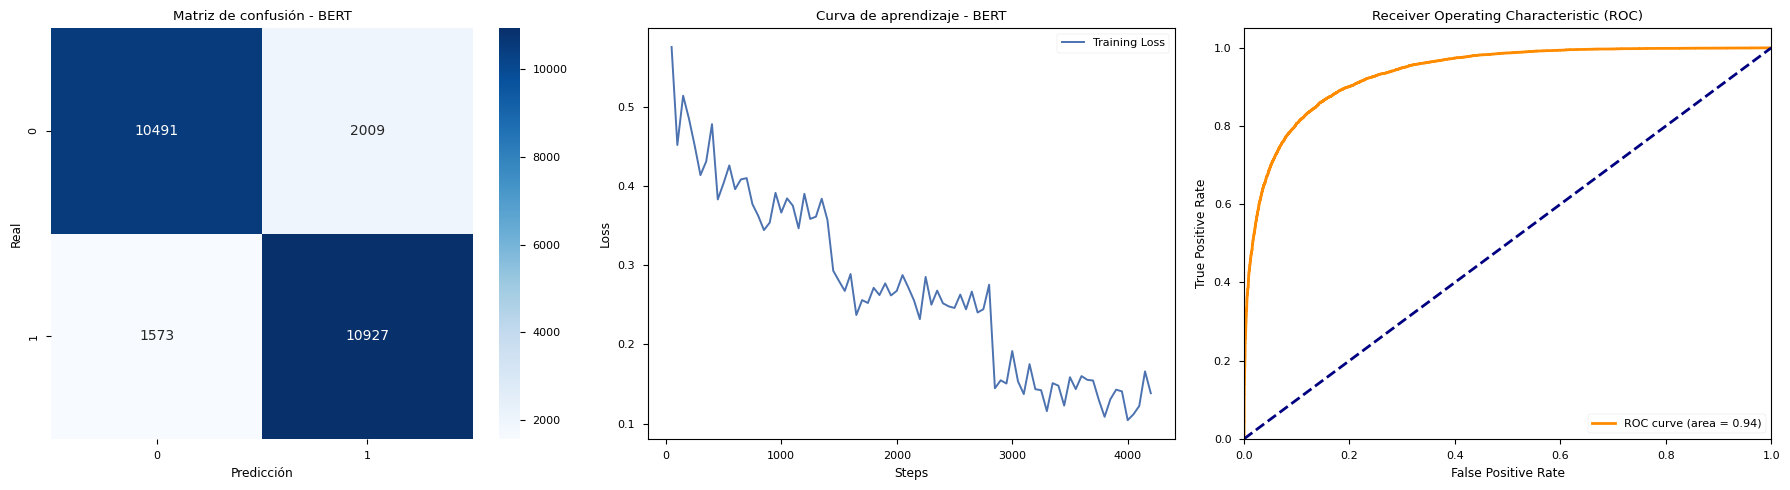


Resultados finales BERT: ACC=0.8567, F1=0.8592


In [4]:
# Entrenamiento del modelo 1: BERT (discriminativo)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

def train_bert():
    MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
    print(f"--- Iniciando entrenamiento de {MODEL_NAME} ---")

    # Tokenizar
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

    train_ds = SentimentDataset(train_encodings, train_labels)
    val_ds = SentimentDataset(val_encodings, val_labels)
    test_ds = SentimentDataset(test_encodings, test_labels)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    ).to(DEVICE)

    # Parámetros (SOTA)
    training_args = TrainingArguments(
        output_dir='./results_bert',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_steps=100,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        seed=42,
        data_seed=42
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )

    # Entrenamiento
    trainer.train()

    # Resultados
    plot_academic_results(trainer, "BERT", test_ds)

    # Liberar memoria
    del model, trainer
    torch.cuda.empty_cache()

# Ejecutar
train_bert()


Iniciando entrenamiento de gpt2


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Tokenizando...


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2599991621.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.325700,0.289901,0.878800,0.878816
2,0.241500,0.266420,0.891200,0.891200
3,0.213800,0.296746,0.896800,0.896786


Evaluando modelo final...


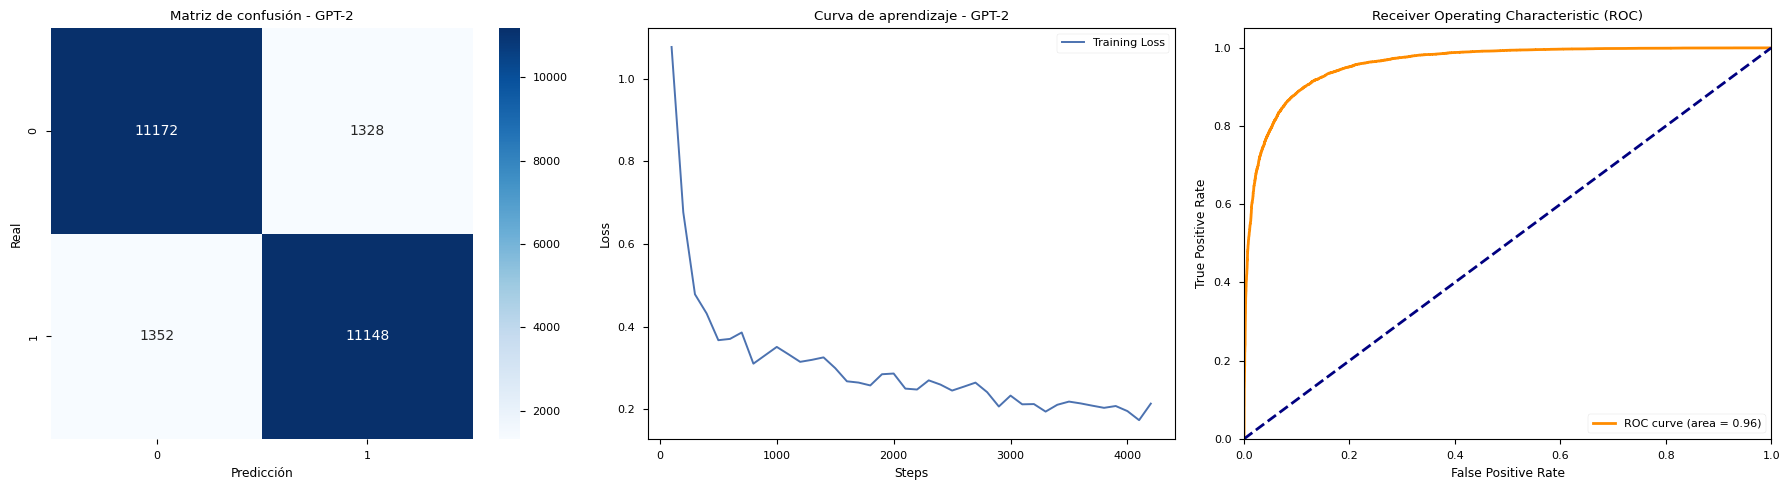


Resultados finales GPT-2: ACC=0.8928, F1=0.8927


In [5]:
# Entrenamiento modelo 2: GPT-2 (generativo)
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, Trainer, TrainingArguments

def train_gpt2_final():
    MODEL_NAME = "gpt2"
    print(f"\nIniciando entrenamiento de {MODEL_NAME}")

    # Tokenizar
    tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
    # GPT-2 no tiene pad token nativo. Se utiliza EOS.
    tokenizer.pad_token = tokenizer.eos_token
    # En clasificación pura, 'right' es el estándar.
    tokenizer.padding_side = "right"

    print("Tokenizando...")
    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

    train_ds = SentimentDataset(train_encodings, train_labels)
    val_ds = SentimentDataset(val_encodings, val_labels)
    test_ds = SentimentDataset(test_encodings, test_labels)

    model = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        device_map="auto"
    )
    model.config.pad_token_id = tokenizer.pad_token_id

    # Parámetros (SOTA)
    training_args = TrainingArguments(
        output_dir='./results_gpt2_final',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=True,
        seed=42,
        data_seed=42
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Entrenamiento
    trainer.train()

    # Resultados
    print("Evaluando modelo final...")
    plot_academic_results(trainer, "GPT-2", test_ds)

    # Limpieza de memoria
    del model, trainer
    torch.cuda.empty_cache()

# Ejecutar
train_gpt2_final()

--- Iniciando entrenamiento de TinyLlama/TinyLlama-1.1B-Chat-v1.0 con LoRA ---


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2766846293.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The model is already on multiple devices. Skipping the move to device specified in `args`.


trainable params: 1,130,496 || all params: 1,035,646,976 || trainable%: 0.1092


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.414500,0.192306,0.927600,0.927573
2,0.308700,0.209961,0.923200,0.923208
3,0.289000,0.254044,0.924000,0.924001


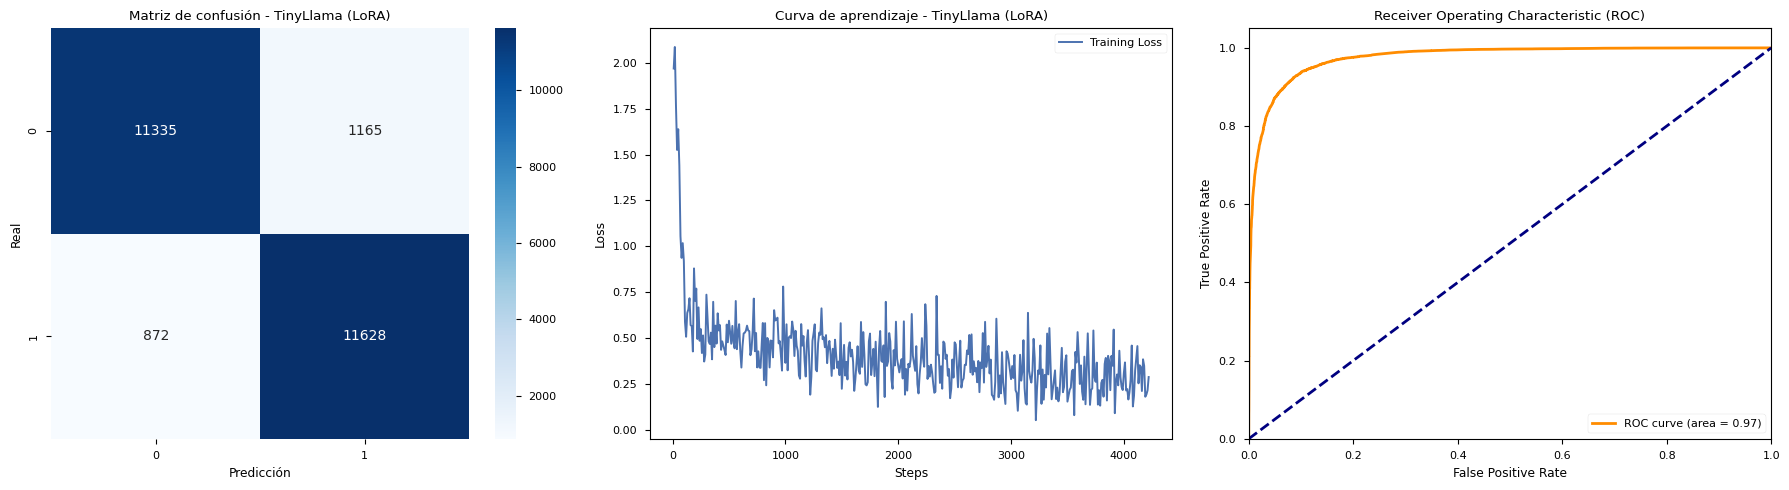


Resultados finales TinyLlama (LoRA): ACC=0.9185, F1=0.9195


In [6]:
# Entrenamiento del modelo 3: LlaMA (generativo)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

def train_llama():
    MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    print(f"--- Iniciando entrenamiento de {MODEL_NAME} con LoRA ---")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    # LLaMA necesita pad token. Se utiliza EOS.
    tokenizer.pad_token = tokenizer.eos_token
    # En clasificación pura, 'right' es el estándar.
    tokenizer.padding_side = "right"

    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

    train_ds = SentimentDataset(train_encodings, train_labels)
    val_ds = SentimentDataset(val_encodings, val_labels)
    test_ds = SentimentDataset(test_encodings, test_labels)

    # Configuración de cuantización
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        torch_dtype=torch.bfloat16,
        device_map={"": 0}
    )
    model.config.pad_token_id = model.config.eos_token_id

    # Configuración LoRA
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["q_proj", "v_proj"]
    )

    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    model = model.to(torch.bfloat16)

    # Parámetros (SOTA)
    training_args = TrainingArguments(
        output_dir='./results_llama',
        learning_rate=2e-4,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        save_steps=100,
        optim="paged_adamw_8bit",
        report_to="none",
        bf16=True,
        seed=42,
        data_seed=42
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Entrenamiento
    trainer.train()

    # Resultados
    plot_academic_results(trainer, "TinyLlama (LoRA)", test_ds)

    # Limpieza de memoria
    del model, trainer
    torch.cuda.empty_cache()

# Ejecutar
train_llama()

In [7]:
# Guardar los modelos entrenados

import shutil
import os

DEST_PATH = "/content/drive/MyDrive/TFG_Data/MODELS"

if not os.path.exists(DEST_PATH):
    os.makedirs(DEST_PATH)
    print(f"Carpeta creada: {DEST_PATH}")

local_folders = ["results_bert", "results_llama", "results_gpt2_final"]

for folder in local_folders:
    src = f"./{folder}"
    dst = f"{DEST_PATH}/{folder}"

    if os.path.exists(src):
        print(f"Guardando {folder} en Drive...")
        if os.path.exists(dst):
            shutil.rmtree(dst) # Se borrar si ya existe para evitar conflictos
        shutil.copytree(src, dst)
        print(f"{folder} guardado correctamente en: {dst}")
    else:
        print(f"No se encontró la carpeta local: {src}.")

Carpeta creada: /content/drive/MyDrive/TFG_Data/MODELS
Guardando results_bert en Drive...
results_bert guardado correctamente en: /content/drive/MyDrive/TFG_Data/MODELS/results_bert
Guardando results_llama en Drive...
results_llama guardado correctamente en: /content/drive/MyDrive/TFG_Data/MODELS/results_llama
Guardando results_gpt2_final en Drive...
results_gpt2_final guardado correctamente en: /content/drive/MyDrive/TFG_Data/MODELS/results_gpt2_final
